In [17]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

<Axes: >

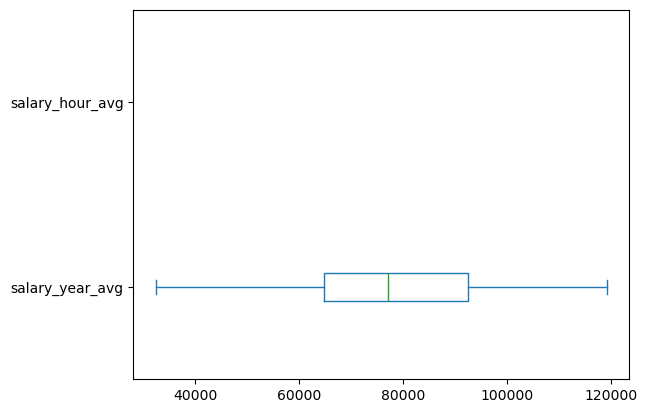

In [18]:
df_DA_india = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

df_DA_india = df_DA_india.dropna(subset=['salary_year_avg'])
df_DA_india['salary_year_avg'].sample(10)

df_DA_india.plot(kind='box', vert=False)

C:\Users\rutvi\AppData\Local\Temp\ipykernel_16684\1733070621.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


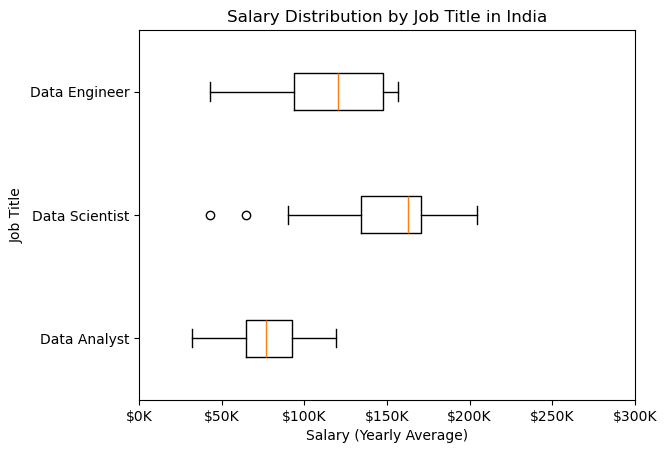

In [36]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_india = df[(df['job_title_short'].isin(job_titles)) & (df['job_location'] == 'India')].copy()
df_india=df_india.dropna(subset=['salary_year_avg'])

job_list = [df_india[df_india['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution by Job Title in India')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 300000)
plt.xlabel('Salary (Yearly Average)')
plt.ylabel('Job Title')
plt.show()

In [ ]:
df_india=df_india.dropna(subset=['salary_year_avg'])


In [25]:
df_india['salary_year_avg']

2022      156500.0
16358     157500.0
29583     119250.0
76651     156000.0
90987      90000.0
            ...   
743931    118140.0
750926    147500.0
770804    155000.0
772920     96773.0
785395     64800.0
Name: salary_year_avg, Length: 62, dtype: float64